# SETUP

In [1]:
# Janky code to do different setup when run in a Colab notebook vs VSCode
import os

from IPython import get_ipython

# ipython = get_ipython()
# # Code to automatically update the HookedTransformer code as its edited without restarting the kernel
# ipython.magic("load_ext autoreload")
# ipython.magic("autoreload 2")
# Import stuff
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
from fancy_einsum import einsum
import tqdm.notebook as tqdm
import random
from pathlib import Path
import plotly.express as px
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from torchtyping import TensorType as TT
from typing import List, Union, Optional, Callable
from functools import partial
import copy
import itertools
import json

from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer
import dataclasses
import datasets
from IPython.display import HTML, Markdown
import umap

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)  # Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

In [3]:
# from neel_plotly import line, imshow, scatter
# import plotly.io as pio
# pio.renderers.default = 'vscode'

#import transformer_lens.patching as patching

from typing_extensions import Literal

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

# import kmapper as km
import sklearn.manifold as manifold
from sklearn.cluster import DBSCAN

import sys
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MaxAbsScaler
import networkx as nx
import pandas as pd


## IOI SETUP

In [4]:
model = HookedTransformer.from_pretrained("gpt2-small")


model.set_use_attn_result(True)
model.set_use_attn_in(True)
model.set_use_hook_mlp_in(True)

Loaded pretrained model gpt2-small into HookedTransformer


In [5]:

import random

def generate_random_ioi_samples(num_samples=10):
    """Generate random IOI-style samples (prompts + (IO, S) answers)."""

    # Some example names, places, objects, and verbs
    names = [
        "John", "Mary", "Tom", "Amy", "James", "Alice", "Mark", "Lisa",
        "Dan", "Max", "Sam", "Eva", "Jane", "Luke", 
        "Bob", "Kate", "Ben"
    ]
    places = [
        "the store", "the park", "the shops", "the beach",
        "the museum", "the school", "the cafe", "the mall"
    ]
    objects = [
        "bag", "ball", "apple", "book", "drink", "gift",
        "sandwich", "toy", "phone", "note"
    ]
    verbs = [
        "gave", "handed", "passed", "offered", "brought",
        "delivered", "presented"
    ]

    prompts = []
    answers = []

    for _ in range(num_samples):
        # Pick 2 distinct names
        name1, name2 = random.sample(names, 2)
        # Pick a place, object, and verb
        place = random.choice(places)
        obj = random.choice(objects)
        verb = random.choice(verbs)

        # Randomly choose who is subject (giver) and who is indirect object (receiver)
        if random.random() < 0.5:
            subject = name1
            indirect_object = name2
        else:
            subject = name2
            indirect_object = name1

        # Construct the prompt
        prompt = f"When {name1} and {name2} went to {place}, {subject} {verb} the {obj} to"

        # The answer is (IO, S) in a tuple
        answers_tuple = (indirect_object, subject)

        prompts.append(prompt)
        answers.append(answers_tuple)

    return prompts, answers

In [6]:
prompts, answers = generate_random_ioi_samples(num_samples=10)

clean_tokens = model.to_tokens(prompts)
# Swap each adjacent pair, with a hacky list comprehension
corrupted_tokens = clean_tokens[
    [(i + 1 if i % 2 == 0 else i - 1) for i in range(len(clean_tokens))]
]
print("Clean string 0", model.to_string(clean_tokens[0]))
print("Corrupted string 0", model.to_string(corrupted_tokens[0]))

answer_token_indices = torch.tensor(
    [
        [model.to_single_token(answers[i][j]) for j in range(2)]
        for i in range(len(answers))
    ],
    device=model.cfg.device,
)
print("Answer token indices", answer_token_indices)

Clean string 0 <|endoftext|>When Kate and John went to the school, Kate offered the phone to
Corrupted string 0 <|endoftext|>When Sam and Tom went to the mall, Tom delivered the drink to
Answer token indices tensor([[ 7554, 45087],
        [16305, 13787],
        [13787, 30730],
        [11518, 44239],
        [45087, 13787],
        [18861, 14731],
        [21174, 11696],
        [24119, 11696],
        [11696,  7554],
        [14731, 40797]], device='cuda:0')


In [7]:
def get_logit_diff(logits, answer_token_indices=answer_token_indices):
    if len(logits.shape) == 3:
        # Get final logits only
        logits = logits[:, -1, :]
    correct_logits = logits.gather(1, answer_token_indices[:, 0].unsqueeze(1))
    incorrect_logits = logits.gather(1, answer_token_indices[:, 1].unsqueeze(1))
    return (correct_logits - incorrect_logits).mean()


clean_logits, clean_cache = model.run_with_cache(clean_tokens)
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

clean_logit_diff = get_logit_diff(clean_logits, answer_token_indices).item()
print(f"Clean logit diff: {clean_logit_diff:.4f}")

corrupted_logit_diff = get_logit_diff(corrupted_logits, answer_token_indices).item()
print(f"Corrupted logit diff: {corrupted_logit_diff:.4f}")

Clean logit diff: 3.6299
Corrupted logit diff: -0.3833


In [8]:
CLEAN_BASELINE = clean_logit_diff
CORRUPTED_BASELINE = corrupted_logit_diff


def ioi_metric(logits, answer_token_indices=answer_token_indices):
    return (get_logit_diff(logits, answer_token_indices) - CORRUPTED_BASELINE) / (
        CLEAN_BASELINE - CORRUPTED_BASELINE
    )

In [9]:
def filter_mlp_hooks(name):
    return "mlp" in name

def get_cache_fwd_and_bwd(model, tokens, metric):
    model.reset_hooks()
    cache = {}

    def forward_cache_hook(act, hook):
        cache[hook.name] = act.detach()

    model.add_hook(filter_mlp_hooks, forward_cache_hook, "fwd")

    grad_cache = {}

    def backward_cache_hook(act, hook):
        grad_cache[hook.name] = act.detach()

    model.add_hook(filter_mlp_hooks, backward_cache_hook, "bwd")

    value = metric(model(tokens))
    value.backward()
    model.reset_hooks()
    return (
        value.item(),
        ActivationCache(cache, model),
        ActivationCache(grad_cache, model),
    )

clean_value, clean_cache, clean_grad_cache = get_cache_fwd_and_bwd(
    model, clean_tokens, ioi_metric
)

corrupted_value, corrupted_cache, corrupted_grad_cache = get_cache_fwd_and_bwd(
    model, corrupted_tokens, ioi_metric
)


In [10]:
def stack_mlp_from_cache(cache, activation_name: Literal["mlp_in", "mlp_out", "pre", "post"]):
    stacked_mlp_vectors = torch.stack(
        [cache[activation_name, l] for l in range(model.cfg.n_layers)], dim=0
    )

    return stacked_mlp_vectors

# Clustering Neurons 

## Computing Attribution Vectors

 - For each neuron we will compute an attribuition score per sample vector.
 - Denote $attr_{x_i}$ the attribution score for neuron $x$ on input $i$.
 - For each neuron $x$ we will compute vector $v_x \in \R^{batch}$ where $v_{x_i} = atr_{x_i}$

In [11]:
num_layers = model.cfg.n_layers

def get_sample_attribution_vectors(clean_cache, sum_over_pos=False):
    clean_act = stack_mlp_from_cache(clean_cache, "post")
    corrupted_act = stack_mlp_from_cache(corrupted_cache, "post")
    grad_vector = stack_mlp_from_cache(corrupted_grad_cache, "post")
    

    if sum_over_pos:
        attribution_scores = einops.reduce(
            grad_vector * (clean_act - corrupted_act),
            "layer batch pos dim -> layer dim batch",
            'sum'
        )
    else:
        attribution_scores = einops.rearrange(
            grad_vector * (clean_act - corrupted_act),
            "layer batch pos dim -> layer (pos dim) batch"
        )
    
    return attribution_scores


def get_sample_activation_vectors(clean_cache, sum_over_pos=False):
    clean_act = stack_mlp_from_cache(clean_cache, "post")

    if sum_over_pos:
        attribution_scores = einops.reduce(
            clean_act,
            "layer batch pos dim -> layer dim batch",
            'sum'
        )
    else:
        attribution_scores = einops.rearrange(
            clean_act,
            "layer batch pos dim -> layer (pos dim) batch"
        )
    
    return attribution_scores

In [12]:
num_layers = model.cfg.n_layers

def stack_w_out():
    W_out_stacked = torch.stack(
        [model.blocks[l].mlp.W_out for l in range(num_layers)], dim=0
    )

    return W_out_stacked


def get_mlp_output_attribution_matrices(clean_cache, sum_over_pos=False, weighted_by_attribution_score=False):
    clean_act_post = stack_mlp_from_cache(clean_cache, "post")

    clean_act_post = einops.reduce(
        clean_act_post,
        "layer batch pos dim -> layer pos dim",
        "sum"
    )

    W_out_stacked = stack_w_out()

    W_out_stacked = einops.rearrange(
        W_out_stacked,
        "layer d_mlp d_embed -> layer d_embed d_mlp"
    )

    attribution_matrices = einops.einsum(
        clean_act_post,
        W_out_stacked,
        "layer pos d_mlp, layer d_embed d_mlp -> layer pos d_embed d_mlp"
    )


    attribution_matrices = einops.rearrange(
        attribution_matrices,
        "layer pos d_embed d_mlp -> layer pos d_mlp d_embed"
    )

    if(weighted_by_attribution_score):
        clean_act = stack_mlp_from_cache(clean_cache, "post")
        corrupted_act = stack_mlp_from_cache(corrupted_cache, "post")
        grad_vector = stack_mlp_from_cache(corrupted_grad_cache, "post")
        
        attribution_scores = einops.reduce(
            grad_vector * (clean_act - corrupted_act),
            "layer batch pos dim -> layer pos dim",
            "sum"
        )

        attribution_matrices = einops.einsum(
            attribution_scores,
            attribution_matrices,
            "layer pos d_mlp, layer pos d_mlp d_embed -> layer pos d_mlp d_embed"
        )

    if(sum_over_pos):
        return einops.reduce(
            attribution_matrices,
            "layer pos d_mlp d_embed -> layer d_mlp d_embed",
            "sum"
        )
    
    else:
        return einops.rearrange(
            attribution_matrices,
            "layer pos d_mlp d_embed -> layer (pos d_mlp) d_embed"
        )


def throw_low_activation_neuron(clean_cache, attributions, threshold=0.1):
    clean_act = stack_mlp_from_cache(clean_cache, "post")
    
    clean_act = einops.reduce(
        torch.abs(clean_act),
        "layer batch pos d_mlp -> layer pos d_mlp",
        "sum"
    )
    
    clean_act = einops.rearrange(
        clean_act,
        "layer pos d_mlp -> layer (pos d_mlp)",
    )
    mask = clean_act > threshold

    while(mask.dim() < attributions.dim()):
        mask = mask.unsqueeze(-1)
    
    
    mask = mask.expand_as(attributions)
    
    filtered_out = attributions * mask
    
    return filtered_out


def throw_low_attribution_neuron(attributions, clean_cache, corrupted_cache, grad_cache, sum_over_pos=False, threshold=0.1):
    clean_act = stack_mlp_from_cache(clean_cache, "post")
    corrupted_act = stack_mlp_from_cache(corrupted_cache, "post")
    grad_vector = stack_mlp_from_cache(grad_cache, "post")
    
    attribution_scores = einops.reduce(
        grad_vector * (clean_act - corrupted_act),
        "layer batch pos d_mlp -> layer pos d_mlp",
        "sum"
    )

    if (sum_over_pos):
        attribution_scores = einops.reduce(
            attribution_scores,
            "layer pos d_mlp -> layer d_mlp",
            "sum"
        )
    else:
        attribution_scores = einops.rearrange(
            attribution_scores,
            "layer pos d_mlp -> layer (pos d_mlp)",
        )

    mask = attribution_scores > threshold

    while(mask.dim() < attributions.dim()):
        mask = mask.unsqueeze(-1)
    
    
    mask = mask.expand_as(attributions)
    
    filtered_out = attributions * mask
    
    return filtered_out




def get_neuron_colors(attr, d_mlp=3072):
    colors = torch.zeros((attr.shape[1]))

    for i in range(attr.shape[1]):
        colors[i] = i//d_mlp

    return colors


# Attribution vector clustering

## Unweighted Clustering

In [13]:
attr = get_mlp_output_attribution_matrices(clean_cache, weighted_by_attribution_score=True, sum_over_pos=True)
#attr = throw_low_activation_neuron(clean_cache, attr, threshold=0.2)
attr = throw_low_attribution_neuron(attr, clean_cache, corrupted_cache, corrupted_grad_cache, sum_over_pos=True, threshold=1e-12)

### Cluster

In [14]:
max_centroids = 5

layer_inertias = []
layer_filtered_inertias = []

for l in range(num_layers):
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    filtered_data = attr[l, non_empty_mask, :].cpu().detach().numpy()
    data = attr[l].cpu().detach().numpy()
    inertias = []
    filtered_inertias = []

    for i in range(1,max_centroids+1):
        kmeans = KMeans(n_clusters=i)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
        kmeans.fit(filtered_data)
        filtered_inertias.append(kmeans.inertia_)
        
    layer_inertias.append(inertias)
    layer_filtered_inertias.append(filtered_inertias)

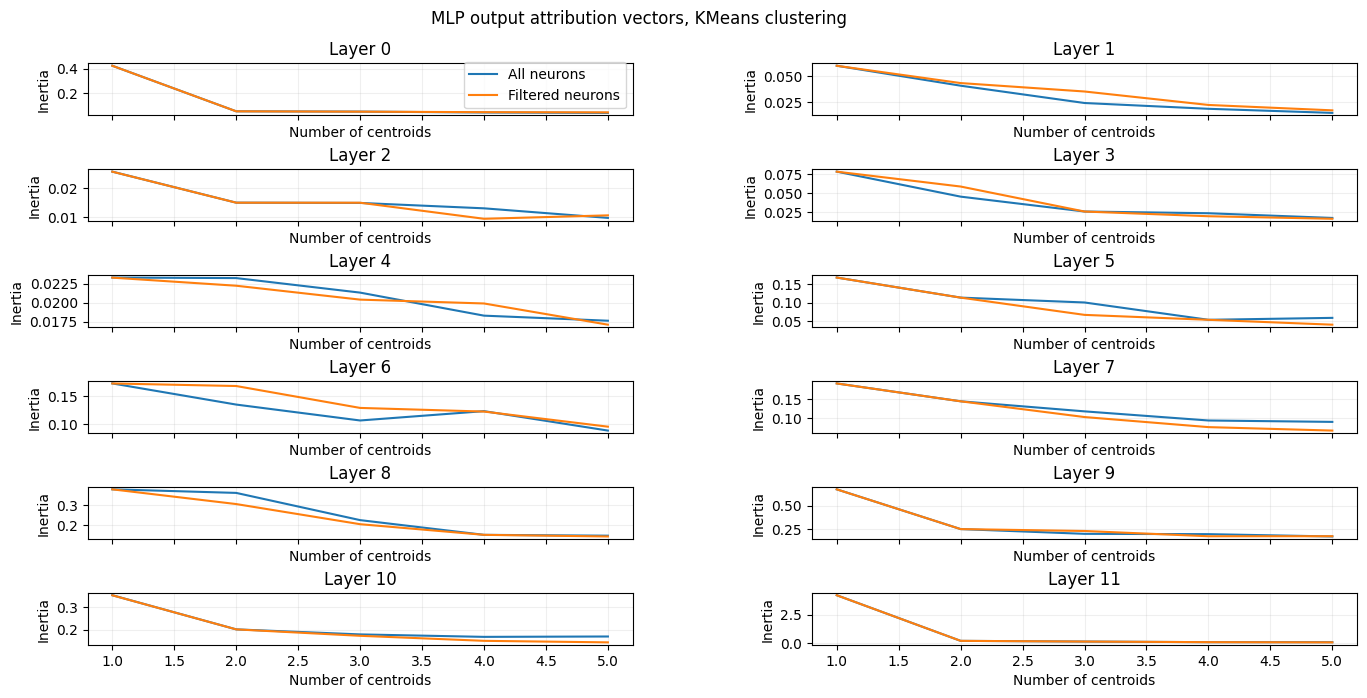

In [15]:
fig, axes = plt.subplots(6, 2, sharex=True, figsize=(7, 8))

l=0
for ax in axes:
    for subplot in ax:
        subplot.set_xlabel("Number of centroids")
        subplot.set_ylabel("Inertia")
        subplot.plot(range(1,max_centroids+1), layer_inertias[l], label="All neurons")
        subplot.plot(range(1,max_centroids+1), layer_filtered_inertias[l], label="Filtered neurons")
        subplot.set_title(f"Layer {l}")
        subplot.grid(alpha=0.2)

        if (l==0): subplot.legend()
        l+=1

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space at top for suptitle
plt.suptitle(f"MLP output attribution vectors, KMeans clustering")
plt.gcf().set_size_inches(15, 7)  # Make the figure wider

### Plot (UMAP after PCA: $\mathbb{R}^{3072}\rightarrow_{\text{PCA}}\mathbb{R}^{128}\rightarrow_{\text{UMAP}}\mathbb{R}^2$ )

In [16]:
# supress all warnings
import warnings
warnings.filterwarnings("ignore")

pca_data = []

all_cols = get_neuron_colors(attr)
filtered_cols = []

for l in range(num_layers):
    non_empty_mask = attr[l].abs().sum(dim=1).bool().cpu().detach()
    filtered_cols.append(all_cols[non_empty_mask].cpu().detach().numpy())
    data = attr[l,non_empty_mask,:].cpu().detach().numpy()

    pca = PCA(n_components=min(data.shape[0], data.shape[1], 128))
    pca_result = pca.fit_transform(data)
    pca_data.append(pca_result)


embeddings = []
for l in range(num_layers):
    reducer = umap.UMAP()
    embeddings.append(reducer.fit_transform(pca_data[l]))

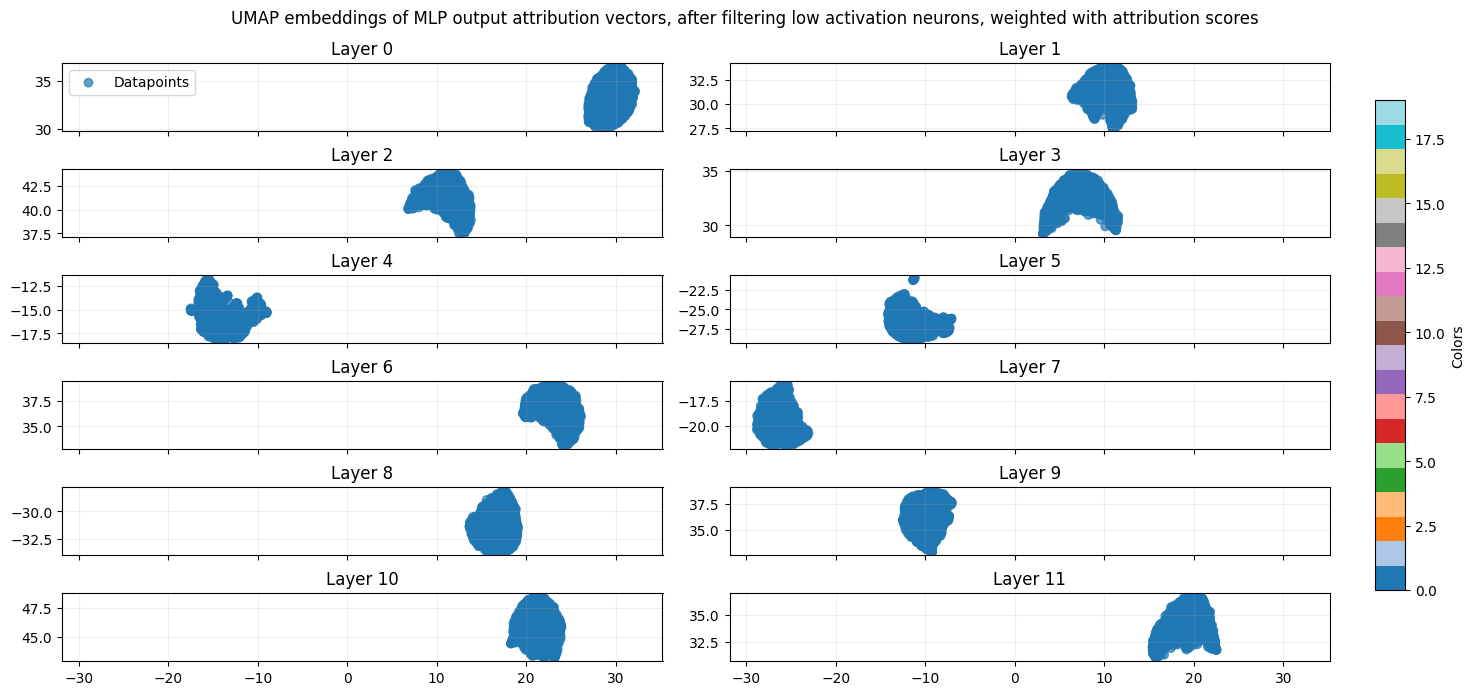

In [17]:
fig, axes = plt.subplots(6, 2, sharex=True, figsize=(15, 8))
cmap = cm.get_cmap('tab20')

norm = mcolors.Normalize(vmin=0, vmax=19)  # Assuming 'tab20' has 20 discrete colors

l=0
for ax in axes:
    for subplot in ax:
        graph = subplot.scatter(embeddings[l][:,0], embeddings[l][:,1], label='Datapoints', c=filtered_cols[l], cmap=cmap, norm=norm, alpha=0.7)
        subplot.set_title(f"Layer {l}")
        subplot.grid(alpha=0.2)

        if (l==0):
            subplot.legend()
        l+=1

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, label='Colors')

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.suptitle('UMAP embeddings of MLP output attribution vectors, after filtering low activation neurons, weighted with attribution scores')
plt.gcf().set_size_inches(15, 7)  # Make the figure wider

### TDA: (regular) mapper alg.

#### Option 1

In [18]:
all_positions = get_neuron_colors(attr)


for l in range(model.cfg.n_layers):
    PATH = "./TDA_visualizations/individual_pos/"+f"layer_{l}"+".html"

    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    data = attr[l,non_empty_mask,:].cpu().detach().numpy()
    layer_pos = all_positions[non_empty_mask].cpu().detach().numpy()

    # Initialize
    mapper = km.KeplerMapper(verbose=1)

    # Fit to and transform the data
    projected_data = mapper.fit_transform(data, 
                                        projection=[manifold.Isomap(n_components=128, n_jobs=-1),
                                                    umap.UMAP(n_components=5)])

    # Create a cover with 10 elements
    cover = km.Cover(n_cubes=10)

    # Create dictionary called 'graph' with nodes, edges and meta-information
    graph = mapper.map(projected_data, data, cover=cover, clusterer=DBSCAN(metric="cosine"))


    if not len(graph["nodes"]) > 0:
        print(f'\n\n\n###NO NODES IN GRAPH LAYER {l}###\n\n\n')
        continue
    
    mapper.visualize(graph,
                    path_html=PATH,
                    title=f"Mapper alg. applied to attribution vectors of layer {l}",
                    color_values =  layer_pos,
                    color_function_name = 'Position',
                    nbins=5,
                    node_color_function = np.array(['average', 'std', 'sum', 'max', 'min']))


RuntimeError: indices should be either on cpu or on the same device as the indexed tensor (cpu)

#### Option 2

In [ ]:
from tdamapper.learn import MapperAlgorithm
from tdamapper.cover import CubicalCover
from tdamapper.plot import MapperPlot


all_positions = get_neuron_colors(attr)

figures = []

for l in range(model.cfg.n_layers):
    # Throw zero neurons
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    data = attr[l,non_empty_mask,:].cpu().detach().numpy()
    layer_pos = all_positions[non_empty_mask].cpu().detach().numpy()


    # PCA then UMAP
    pca = PCA(n_components=min(data.shape[0], data.shape[1], 256))
    reducer = umap.UMAP(n_components=5)
    transformed_data = reducer.fit_transform(pca.fit_transform(data))


    cover = CubicalCover(n_intervals=15, overlap_frac=0.2)
    clust = DBSCAN(metric='cosine')
    graph = MapperAlgorithm(cover, clust).fit_transform(data, transformed_data)

    # color according to labels
    fig = MapperPlot(graph, dim=3, iterations=600)
    fig = fig.plot_plotly(
        colors = layer_pos,                       # color according to categorical values
        cmap='tealrose',                     # Jet colormap, for classes
        agg=np.nanmean,                 # aggregate on nodes according to mean
        width=600,
        height=600)
    
    figures.append(fig)
    #fig.show(config={'scrollZoom': True})

Plots a single graph (do this)

In [ ]:
figures[10]

Plots all graphs, not recommended

In [ ]:
from plotly.subplots import make_subplots

# Create a 2x2 grid figure
grid_fig = make_subplots(rows=6, cols=2, subplot_titles=[f'Layer {l}' for l in range(model.cfg.n_layers)])

# Add each figure's traces to the appropriate subplot
for i, fig in enumerate(figures):
    row = i // 2 + 1
    col = i % 2 + 1
    for trace in fig.data:
        grid_fig.add_trace(trace, row=row, col=col)
    # Optionally, adjust the layout of the subplot (axes labels, etc.)
    
grid_fig.update_layout(height=1080, width=1920, showlegend=False)
grid_fig.show(config={'scrollZoom' : True, 'title' : 'Mapper alg. on attribution vectors of all positions'})


### TDA: D-mapper alg. ("A distribution-guided Mapper algorithm" - Yuyang Tao and Shufei Ge)

In [ ]:
all_positions = get_neuron_colors(attr)


for l in range(model.cfg.n_layers):
    PATH = "./TDA_visualizations/D_mapper/weighted_sum_over_pos/"+f"layer_{l}"+".html"

    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    data = attr[l,non_empty_mask,:].cpu().detach().numpy()
    layer_pos = all_positions[non_empty_mask].cpu().detach().numpy()


    projected_data = mapper.fit_transform(data, 
                                        projection=[manifold.Isomap(n_components=128, n_jobs=-1),
                                                    umap.UMAP(n_components=1)])

    n = 10
    a = 0.006
    cover = km.D_Cover(n_cubes=n,alpha = a,tol = 1*1e-8,n_init=15)

    mapper = km.D_Mapper()

    graph = mapper.map(projected_data, data, cover=cover, clusterer=DBSCAN(metric="cosine"))


    if not len(graph["nodes"]) > 0:
        print(f'\n\n\n###NO NODES IN GRAPH LAYER {l}###\n\n\n')
        continue
    
    mapper.visualize(graph,
                    path_html=PATH,
                    title=f"Mapper alg. applied to attribution vectors of layer {l}",
                    # color_values =  layer_pos,
                    # color_function_name = 'Position',
                    # nbins=5,
                    node_color_function = np.array(['average', 'std', 'sum', 'max', 'min']))

## Weighted Clustering

In [19]:
attr = get_mlp_output_attribution_matrices(clean_cache, weighted_by_attribution_score=False)
#attr = throw_low_activation_neuron(clean_cache, attr, threshold=2)
attr = throw_low_attribution_neuron(attr, clean_cache, corrupted_cache, corrupted_grad_cache, threshold=1e-15)

### Cluster

In [20]:
max_centroids = 5

layer_inertias = []
layer_filtered_inertias = []

for l in range(num_layers):
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    filtered_data = attr[l, non_empty_mask, :].cpu().detach().numpy()
    data = attr[l].cpu().detach().numpy()
    inertias = []
    filtered_inertias = []

    for i in range(1,max_centroids+1):
        kmeans = KMeans(n_clusters=i)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
        kmeans.fit(filtered_data)
        filtered_inertias.append(kmeans.inertia_)
        
    layer_inertias.append(inertias)
    layer_filtered_inertias.append(filtered_inertias)

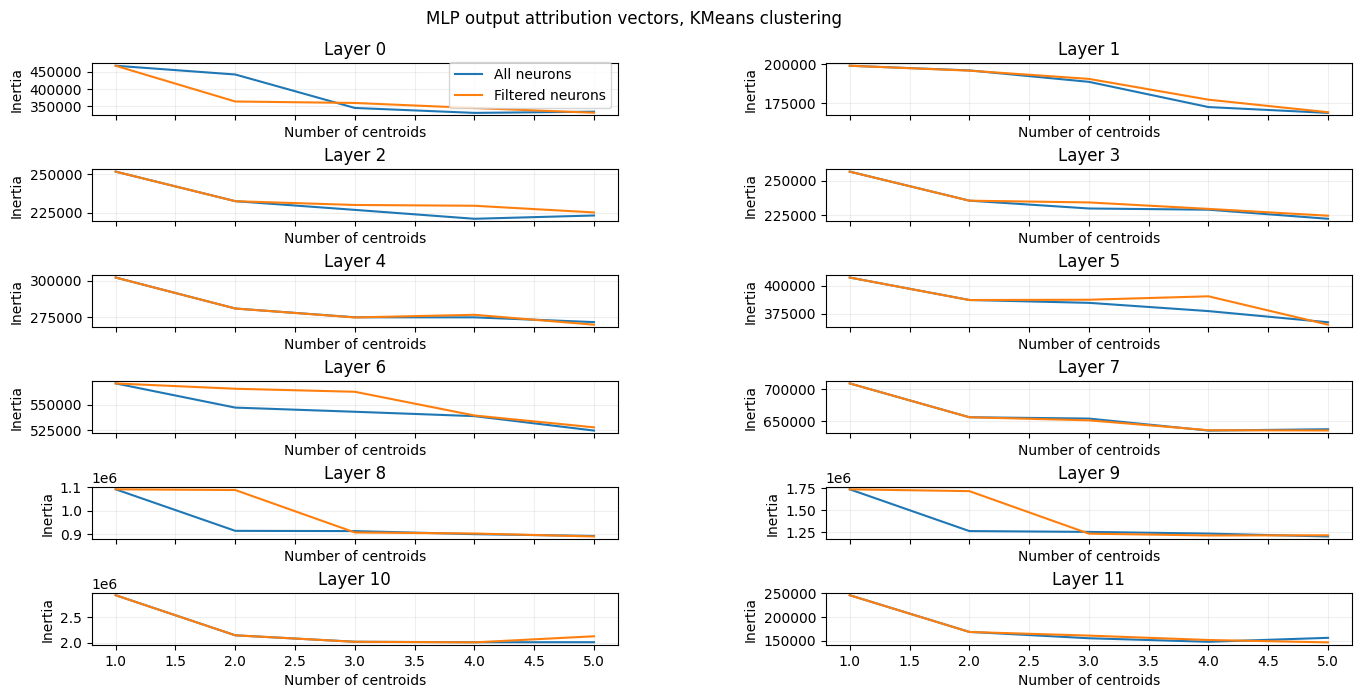

In [21]:
fig, axes = plt.subplots(6, 2, sharex=True, figsize=(7, 8))

l=0
for ax in axes:
    for subplot in ax:
        subplot.set_xlabel("Number of centroids")
        subplot.set_ylabel("Inertia")
        subplot.plot(range(1,max_centroids+1), layer_inertias[l], label="All neurons")
        subplot.plot(range(1,max_centroids+1), layer_filtered_inertias[l], label="Filtered neurons")
        subplot.set_title(f"Layer {l}")
        subplot.grid(alpha=0.2)

        if(l==0): subplot.legend()

        l+=1

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space at top for suptitle
plt.suptitle(f"MLP output attribution vectors, KMeans clustering")
plt.gcf().set_size_inches(15, 7)  # Make the figure wider

### Plot

In [23]:
pca_data = []

all_cols = get_neuron_colors(attr)
filtered_cols = []

for l in range(num_layers):
    non_empty_mask = attr[l].abs().sum(dim=1).bool().cpu().detach()
    data = attr[l,non_empty_mask,:].cpu().detach().numpy()
    filtered_cols.append(all_cols[non_empty_mask].cpu().detach().numpy())

    pca = PCA(n_components=min(data.shape[0], data.shape[1], 128))
    pca_result = pca.fit_transform(data)
    pca_data.append(pca_result)


embeddings = []
for l in range(num_layers):
    reducer = umap.UMAP()
    embeddings.append(reducer.fit_transform(pca_data[l]))


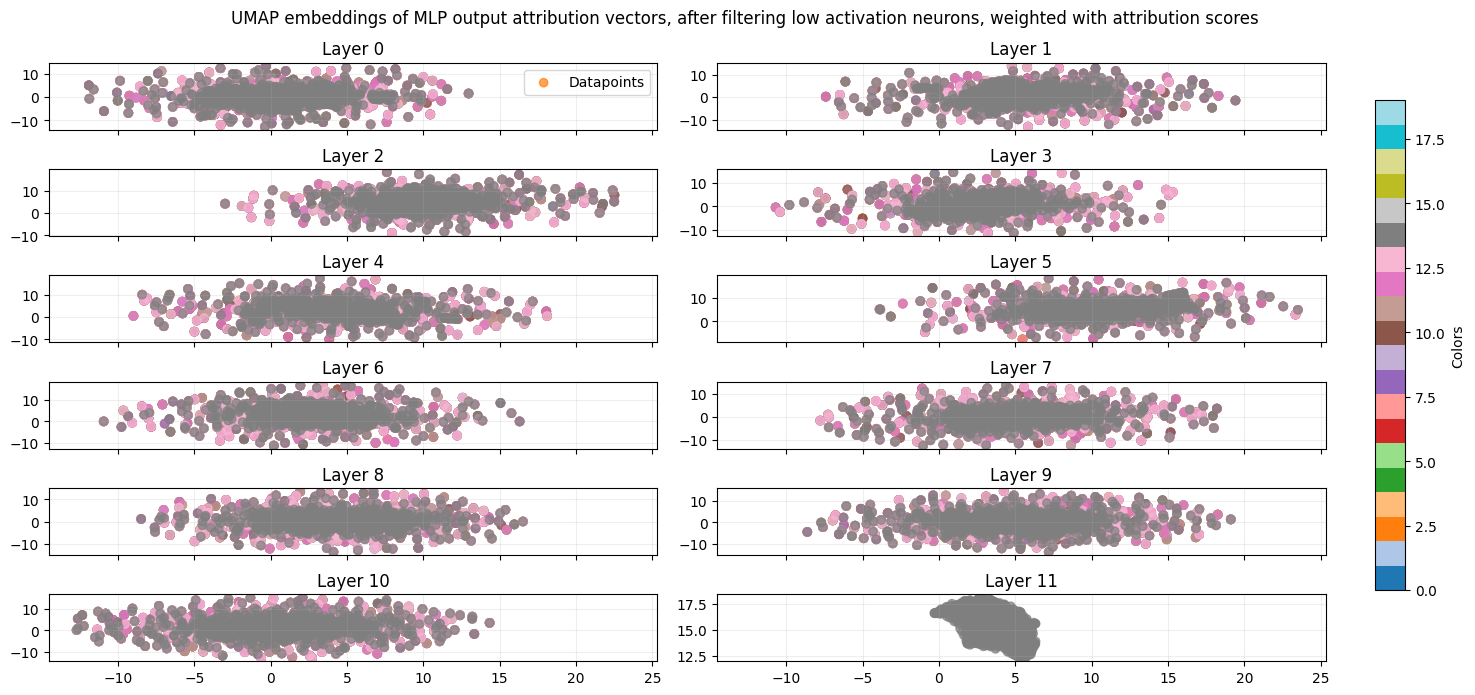

In [24]:
fig, axes = plt.subplots(6, 2, sharex=True, figsize=(15, 8))
cmap = cm.get_cmap('tab20')

norm = mcolors.Normalize(vmin=0, vmax=19)  # Assuming 'tab20' has 20 discrete colors

l=0
for ax in axes:
    for subplot in ax:
        graph = subplot.scatter(embeddings[l][:,0], embeddings[l][:,1], label='Datapoints', c=filtered_cols[l], cmap=cmap, norm=norm, alpha=0.7)
        subplot.set_title(f"Layer {l}")
        subplot.grid(alpha=0.2)

        if (l==0):
            subplot.legend()
        l+=1

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, label='Colors')

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.suptitle('UMAP embeddings of MLP output attribution vectors, after filtering low activation neurons, weighted with attribution scores')
plt.gcf().set_size_inches(15, 7)  # Make the figure wider


### Clustering 2.0! (After filtering, recognizing 'elbow' point automatically)

In [25]:
max_centroids = 5
min_centroids = 1
centroids = {}

best_ks = []
final_cluster_labels = []
final_inertias = []

k=1
for l in range(num_layers):    
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    data = attr[l, non_empty_mask, :].cpu().detach().numpy()
    inertias = []
    current_centroids = []
    sil_score = []
    layer_cluster_labels = []

    for i in range(min_centroids, max_centroids+1):
        kmeans = KMeans(n_clusters=i)
        cluster_labels = kmeans.fit_predict(data)

        layer_cluster_labels.append(cluster_labels)
        current_centroids.append(kmeans.cluster_centers_)

        if(i != 1):
            sil_score.append(silhouette_score(data, cluster_labels))
        inertias.append(kmeans.inertia_)
        
    k = sil_score.index(max(sil_score)) + max(min_centroids, 2)
    best_ks.append(k)
    
    final_cluster_labels.append(layer_cluster_labels)
    centroids[l] = current_centroids[k - max(min_centroids, 2) + 1]

    final_inertias.append(inertias)

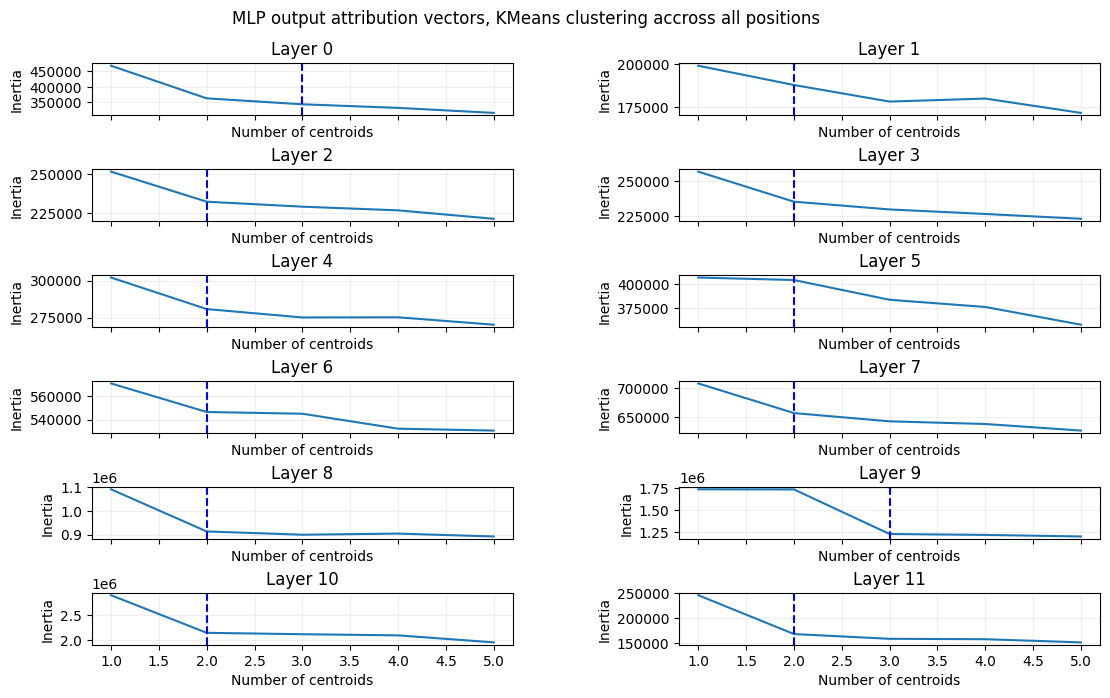

In [26]:
fig, axes = plt.subplots(6, 2, sharex=True, figsize=(7, 8))

l=0
for ax in axes:

    for subplot in ax:
        subplot.set_xlabel("Number of centroids")
        subplot.set_ylabel("Inertia")
        
        subplot.plot(range(min_centroids,max_centroids+1), final_inertias[l])
        subplot.axvline(x = best_ks[l], color = 'b', linestyle = '--')

        subplot.set_title(f"Layer {l}")
        subplot.grid(alpha=0.2)

        l+=1

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space at top for suptitle
plt.suptitle(f"MLP output attribution vectors, KMeans clustering accross all positions")
plt.gcf().set_size_inches(12, 7)  # Make the figure wider

### Plot

In [27]:
pca_data = []
for l in range(num_layers):
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    data = attr[l,non_empty_mask,:].cpu().detach().numpy()
    combined_data = np.concatenate([data, centroids[l]], axis=0)

    pca = PCA(n_components=min(combined_data.shape[0], combined_data.shape[1], 128))
    pca_result = pca.fit_transform(combined_data)
    pca_data.append(pca_result)


embeddings = []
for l in range(num_layers):
    reducer = umap.UMAP()
    embeddings.append(reducer.fit_transform(pca_data[l]))


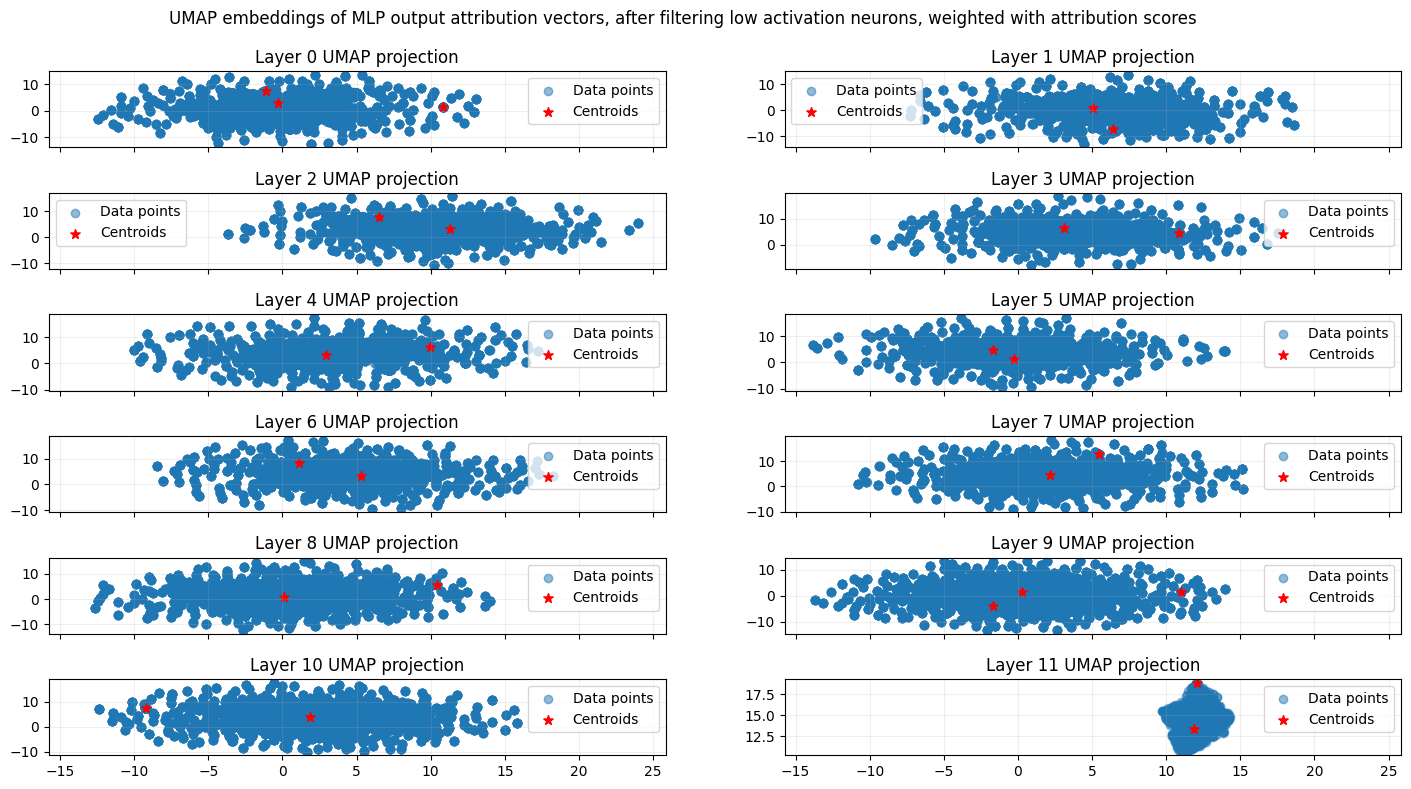

In [28]:
fig, axes = plt.subplots(6, 2, sharex=True, figsize=(7, 8))

l=0
for ax in axes:
    for subplot in ax:
        non_empty_mask = attr[l].abs().sum(dim=1).bool()
        data = attr[l,non_empty_mask,:].cpu().detach().numpy()
        
        subplot.scatter(embeddings[l][:len(data), 0], embeddings[l][:len(data), 1], alpha=0.5, label='Data points')
        subplot.scatter(embeddings[l][len(data):, 0], embeddings[l][len(data):, 1], c='red', marker='*', s=50, label='Centroids')
        subplot.set_title(f'Layer {l} UMAP projection')
        subplot.legend()
        subplot.grid(alpha=0.2)

        l+=1

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space at top for suptitle
plt.suptitle('UMAP embeddings of MLP output attribution vectors, after filtering low activation neurons, weighted with attribution scores')
plt.gcf().set_size_inches(15, 8)  # Make the figure wider

## Interpreting clusters

### Position counts in each cluster

In [29]:
clusterings = []

for l in range(model.cfg.n_layers):
    layer_clustering = {
        i:0 for i in range(6)
    }

    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    data = attr[l, non_empty_mask, :].cpu().detach().numpy()

    for j in range(data.shape[0]):
        layer_clustering[final_cluster_labels[l][best_ks[l]-1][j]] += 1

    clusterings.append(layer_clustering)

for l in range(model.cfg.n_layers):
    print(f"layer {l}:")
    print(clusterings[l])


layer 0:
{0: 19872, 1: 25, 2: 2, 3: 0, 4: 0, 5: 0}
layer 1:
{0: 8, 1: 19847, 2: 0, 3: 0, 4: 0, 5: 0}
layer 2:
{0: 51, 1: 19915, 2: 0, 3: 0, 4: 0, 5: 0}
layer 3:
{0: 19988, 1: 33, 2: 0, 3: 0, 4: 0, 5: 0}
layer 4:
{0: 31, 1: 20060, 2: 0, 3: 0, 4: 0, 5: 0}
layer 5:
{0: 6, 1: 19960, 2: 0, 3: 0, 4: 0, 5: 0}
layer 6:
{0: 104, 1: 19909, 2: 0, 3: 0, 4: 0, 5: 0}
layer 7:
{0: 19836, 1: 10, 2: 0, 3: 0, 4: 0, 5: 0}
layer 8:
{0: 19933, 1: 6, 2: 0, 3: 0, 4: 0, 5: 0}
layer 9:
{0: 34, 1: 10, 2: 20066, 3: 0, 4: 0, 5: 0}
layer 10:
{0: 20025, 1: 41, 2: 0, 3: 0, 4: 0, 5: 0}
layer 11:
{0: 2, 1: 1540, 2: 0, 3: 0, 4: 0, 5: 0}


In [32]:
def get_cluster_pos_proportion(final_cluster_labels, attr, all_positions, num_positions):
    num_clusters = max([final_cluster_labels[l][best_ks[l]-1].max() for l in range(num_layers)]) + 1

    all_cluster_counts = []
    for l in range(num_layers):
        cluster_counts = np.zeros((num_clusters, num_positions))

        non_empty_mask = attr[l].abs().sum(dim=1).bool().cpu().detach()
        data = attr[l, non_empty_mask, :].cpu().detach().numpy()
        positions = all_positions[non_empty_mask].cpu().detach().numpy().astype(np.int16)

        for i in range(data.shape[0]):
            cluster_counts[final_cluster_labels[l][best_ks[l]-1][i], positions[i]] += 1

        cluster_counts /= data.shape[0]

        all_cluster_counts.append(cluster_counts)

    return np.array(all_cluster_counts)

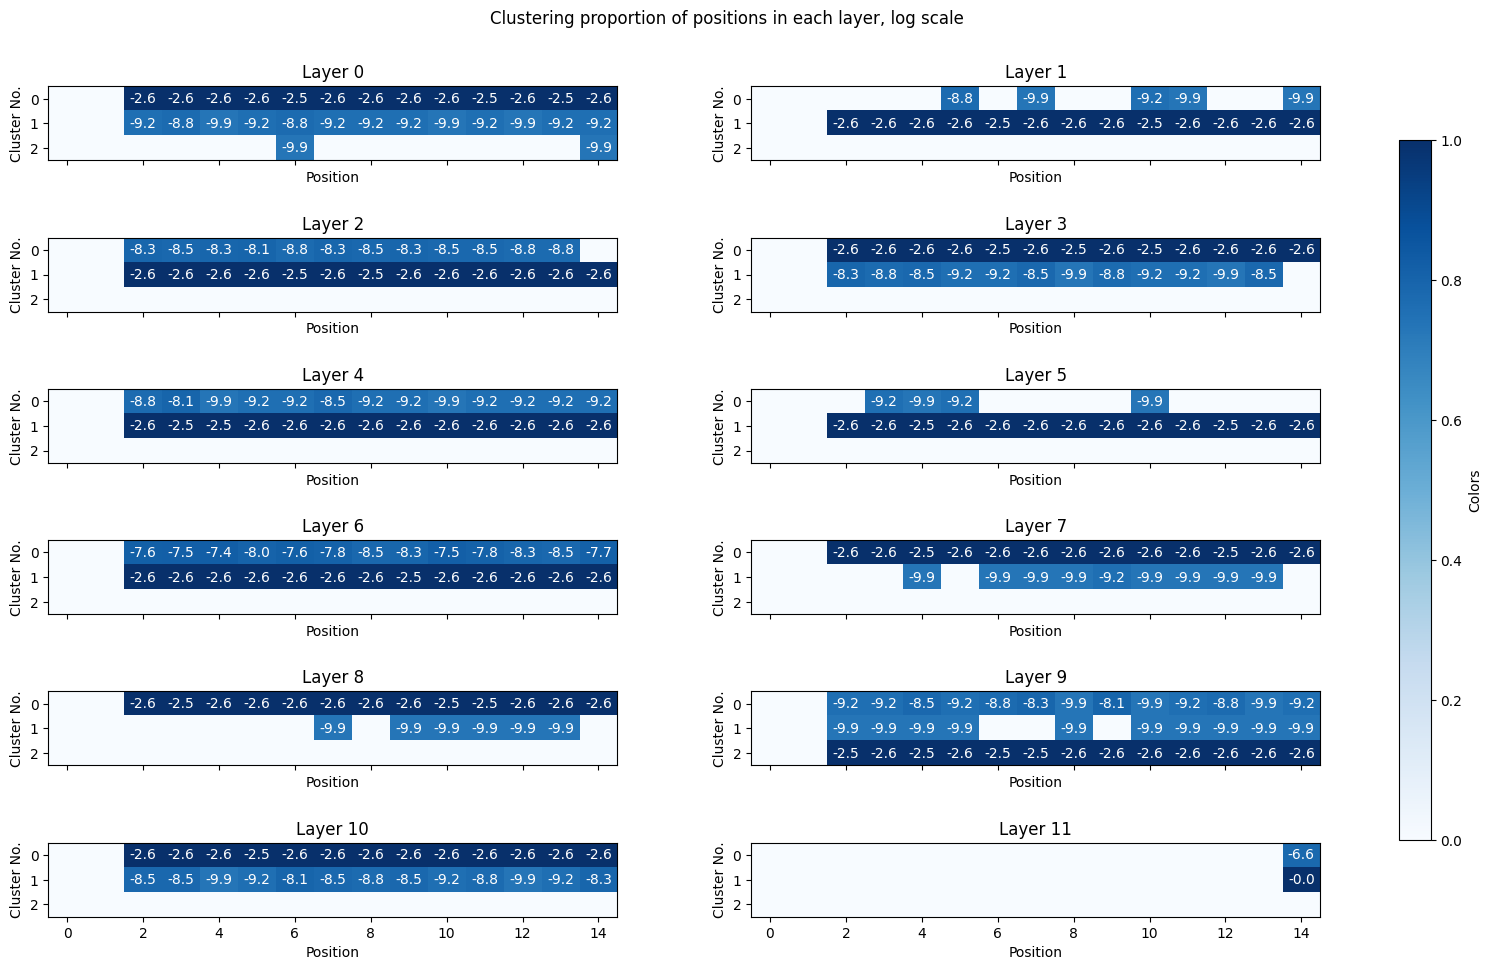

In [33]:
layer_cluster_pos_prop = get_cluster_pos_proportion(final_cluster_labels, attr, get_neuron_colors(attr), 15)

fig, axes = plt.subplots(6, 2, sharex=True, figsize=(7, 8))

l=0
for ax in axes:

    for subplot in ax:
        subplot.imshow(np.log(layer_cluster_pos_prop[l]+1e-13), cmap='Blues', aspect='auto')

        for (i, j), val in np.ndenumerate(layer_cluster_pos_prop[l]):
            subplot.text(j, i, f'{round(np.log(val),1) if val != 0 else ""}', ha='center', va='center', color='white')

        subplot.set_xlabel("Position")
        subplot.set_ylabel("Cluster No.")
        subplot.set_title(f"Layer {l}")

        subplot.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

        l+=1


cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cm.ScalarMappable(cmap='Blues'), cax=cbar_ax, label='Colors')

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.suptitle(f"Clustering proportion of positions in each layer, log scale")
plt.gcf().set_size_inches(16, 10)  # Make the figure wider

# Activation vectors clustering (entry is act on sample)

In [34]:
X = get_sample_activation_vectors(clean_cache, sum_over_pos=True)
X = throw_low_attribution_neuron(X, clean_cache, corrupted_cache, corrupted_grad_cache, sum_over_pos=True, threshold=1e-13)

## Clustering

In [35]:

clusterer = DBSCAN(eps=0.3, min_samples=16)

all_layers_clusters = []
for l in range(num_layers):
    non_empty_mask = X[l].abs().sum(dim=1).bool()
    filtered_data = X[l, non_empty_mask, :].cpu().detach().numpy()

    c = clusterer.fit(filtered_data)
    all_layers_clusters.append(c)

In [36]:
for l in range(num_layers): 
    print(set(all_layers_clusters[l].labels_))
    print(pd.Series(all_layers_clusters[l].labels_).value_counts(normalize=True).reset_index())

{-1}
   index  proportion
0     -1         1.0
{-1}
   index  proportion
0     -1         1.0
{-1}
   index  proportion
0     -1         1.0
{-1}
   index  proportion
0     -1         1.0
{-1}
   index  proportion
0     -1         1.0
{-1}
   index  proportion
0     -1         1.0
{-1}
   index  proportion
0     -1         1.0
{-1}
   index  proportion
0     -1         1.0
{-1}
   index  proportion
0     -1         1.0
{-1}
   index  proportion
0     -1         1.0
{-1}
   index  proportion
0     -1         1.0
{-1}
   index  proportion
0     -1         1.0


## Visualization

## Evaluation (still unclear)